In [255]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import array_to_latex
import numpy as np

In [256]:
# finds the closest int larger than input that is a power of 2
def next_power_of_2(n: int) -> int:
    return 1 << (n - 1).bit_length() # bit shift

# input int and output np.ndarray
def haar_matrix_builder(n: int) -> np.ndarray:

    # base case and dim check
    assert n > 0 and (n & (n - 1)) == 0, "n must be power of 2"
    if n == 1:
        return np.array([[1.0]], dtype=float)

    half = n // 2
    norm = 1.0 / np.sqrt(2.0)

    # build the a haar level
    B = np.zeros((n, n), dtype=float)
    for k in range(half):
        col1 = 2 * k
        col2 = 2 * k + 1
        B[k, col1] = norm
        B[k, col2] = norm
        B[half+k, col1] = norm
        B[half+k, col2] = -norm

    # recursive call to build haar levels
    W_half = haar_matrix_builder(half)

    # after hitting base case multiply all haar levels
    R = np.block([
        [W_half, np.zeros((half, half), dtype=float)],
        [np.zeros((half, half), dtype=float), np.eye(half, dtype=float)]
    ])

    return R @ B

# input np.ndarray and output np.ndarray
def haar_transform_2d_classical(x: np.ndarray, inverse=False) -> np.ndarray:
    # build the haar transform classically
    H, W = x.shape
    WH = haar_matrix_builder(H)
    WW = haar_matrix_builder(W)

    # inverse if true
    if inverse:
        WH = WH.T
        WW = WW.T

    #print(f"{WH}\n\n\n")

    # apply the haar transform
    return WH @ x @ WW.T

Quantum Output:
 [[ 0.91442991  0.12204016 -0.02350484 -0.02118513]
 [ 0.0491792  -0.15077581 -0.08658321 -0.09108147]
 [ 0.00180456  0.05328093  0.01119008  0.10257259]
 [ 0.14389606 -0.18540747  0.18784657  0.05587149]]

Classical Output:
 [[ 0.91442991  0.12204016 -0.02350484 -0.02118513]
 [ 0.0491792  -0.15077581 -0.08658321 -0.09108147]
 [ 0.00180456  0.05328093  0.01119008  0.10257259]
 [ 0.14389606 -0.18540747  0.18784657  0.05587149]]


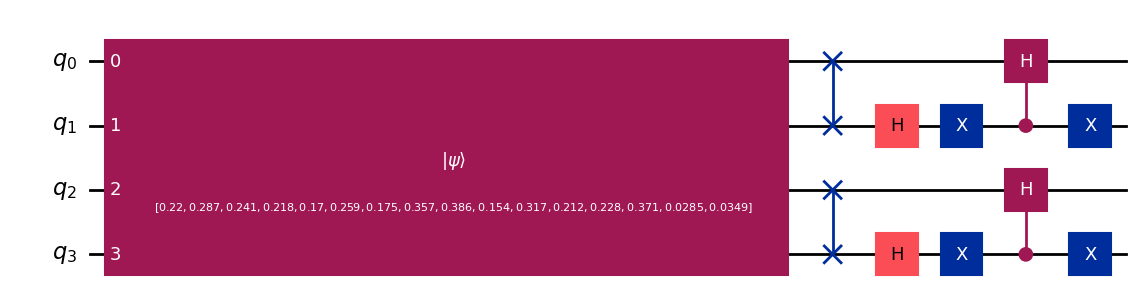

In [257]:
np.random.seed(0)
X = np.random.rand(4, 4).astype(float)
# print(X)

psi = X.flatten()
norm = np.linalg.norm(psi)
amps = psi / norm

col_qubits = list(range(2))
row_qubits = list(range(2,4))

qc = QuantumCircuit(4)
qc.initialize(amps, list(range(4)))
qc.swap(0,1)
qc.h(1)
qc.x(1)
qc.ch(1,0)
qc.x(1)
qc.swap(2,3)
qc.h(3)
qc.x(3)
qc.ch(3,2)
qc.x(3)

sv_ideal = Statevector.from_instruction(qc).data
Yq_ideal = sv_ideal.reshape(4, 4)
print("Quantum Output:\n", Yq_ideal.real)

Yc = haar_transform_2d_classical(X) / norm
print("\nClassical Output:\n", Yc)

# qc_op = Operator.from_circuit(qc)
# latex_circuit = array_to_latex(
#     qc_op.data,
#     max_size=qc_op.data.shape,
#     precision=3
# )
# display(latex_circuit)

display(qc.draw(output="mpl"))